<h1 align="center"><strong>A tail-scarcity case study: deep generative models vs. extreme value theory</strong></h1>
<h2 align="center">Can a VAE generate plausible extreme scenarios?</h2>

## 1. Motivation

Generating *synthetic crisis scenarios* is an appealing answer to a fundamental problem in climate-risk and infrastructure-resilience modelling: the events we care most about are the ones we have almost no data for. Deep generative models (VAEs, GANs) are increasingly proposed to enrich scarce historical records with plausible synthetic events.

But this raises a question that is rarely checked: do these models actually reproduce the tail behaviour of the data? A synthetic scenario generator that systematically under-produces extreme events is worse than useless for resilience planning, leading to manufactured false confidence.

This notebook is a small, fully controlled experiment:

1. Simulate a heavy-tailed "hazard intensity" variable with a known tail index (so we know the ground truth).
2. Train a standard Gaussian VAE on it.
3. Use extreme value theory (EVT) diagnostics like survival functions, QQ plots, and the Hill estimator to measure how badly the VAE distorts the tail.
4. Propose and validate a simple corrective: a VAE-bulk / GPD-tail hybrid built with the peaks-over-threshold (POT) method.

The point is not the toy itself, but the methodology. EVT provides both the diagnostic and the fix for the tail pathologies of deep generative models. This is directly relevant to using generative AI for crisis-scenario enrichment when historical extremes are scarce.

## 2. A synthetic hazard with a known heavy tail

We simulate a positive "hazard intensity" $X$ (think: peak wind-gust load on an infrastructure site during a storm) as the absolute value of a Student-$t$ with $\nu = 3$ degrees of freedom, rescaled:

$$X = 10\,|T_{\nu=3}|$$

This is a **regularly varying** distribution: $P(X > x) \sim C x^{-\alpha}$ with tail index $\alpha = \nu = 3$. Heavy tails of this kind are empirically documented for extreme wind speeds, precipitation and flood discharges and $\alpha = 3$ means the tail is heavy enough that the largest observation in a sample keeps growing dramatically with sample size, which is exactly the regime where crisis planning is hard.

Working with synthetic data is a feature here, not a limitation. Because we know the true tail index, so we can measure the generative model's tail error exactly.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
torch.manual_seed(0)
np.random.seed(0)

N = 20_000
ALPHA_TRUE = 3.0                               
x = np.abs(stats.t.rvs(df=ALPHA_TRUE, size=N)) * 10.0

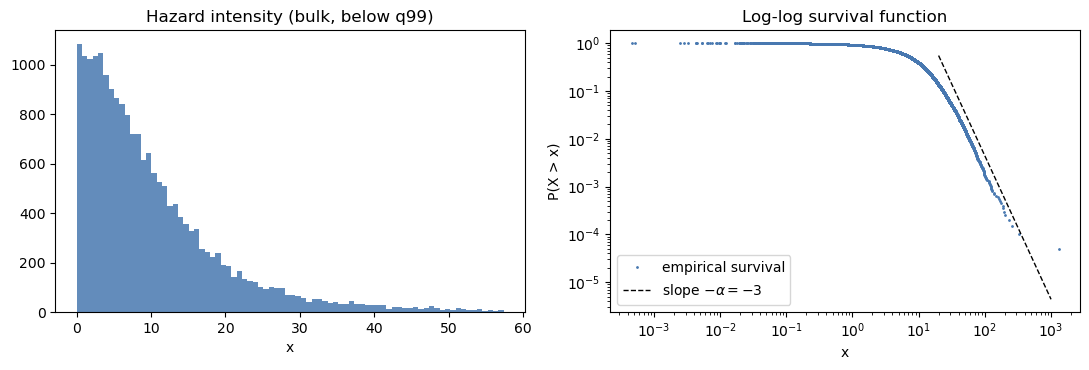

n = 20000 | q95 = 31.7 | q99 = 57.4 | q99.9 = 121.8 | max = 1302.3


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(x[x < np.quantile(x, 0.99)], bins=80, color="#4878b0", alpha=0.85)
ax[0].set(title="Hazard intensity (bulk, below q99)", xlabel="x")

xs = np.sort(x)
surv = 1.0 - np.arange(1, N + 1) / (N + 1)
ax[1].loglog(xs, surv, ".", ms=2, color="#4878b0", label="empirical survival")
ref = np.array([20, 1000.0])
ax[1].loglog(ref, 0.55 * (ref / ref[0]) ** -ALPHA_TRUE, "k--", lw=1, label=r"slope $-\alpha=-3$")
ax[1].set(title="Log-log survival function", xlabel="x", ylabel="P(X > x)")
ax[1].legend()
plt.tight_layout(); plt.show()

print(f"n = {N} | q95 = {np.quantile(x,.95):.1f} | q99 = {np.quantile(x,.99):.1f} "
      f"| q99.9 = {np.quantile(x,.999):.1f} | max = {x.max():.1f}")

The straight line in the log-log survival plot is the signature of a power-law (Pareto-type) tail. Note the spread between the 99.9% quantile and the sample maximum, an order of magnitude. That gap is the crisis-planning problem.

## 3. A standard Gaussian VAE

We train the vanilla architecture that a practitioner would reach for first:

- encoder $q_\phi(z \mid x) = \mathcal N(\mu_\phi(x), \sigma^2_\phi(x))$, latent dimension 2
- Gaussian prior $p(z) = \mathcal N(0, I)$
- decoder $p_\theta(x \mid z) = \mathcal N(\mu_\theta(z), \sigma^2_\theta(z))$ with a learned observation variance (so the model has at least some freedom to widen its output distribution)
- trained by maximising the ELBO:

$$\mathcal L(\theta,\phi) \;=\; \mathbb E_{q_\phi(z\mid x)}\big[\log p_\theta(x\mid z)\big]\;-\;\mathrm{KL}\big(q_\phi(z\mid x)\,\|\,p(z)\big)$$

Data are standardised before training (as is standard practice), and de-standardised for evaluation.

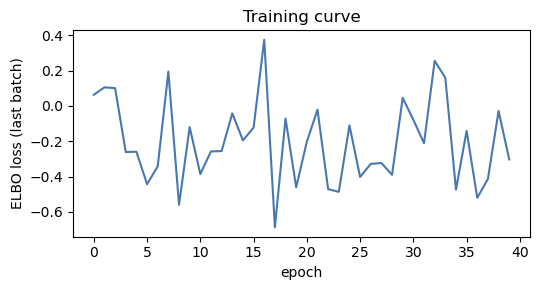

In [6]:
class VAE(nn.Module):
    def __init__(self, latent=2, hidden=64):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(1, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU())
        self.mu_z = nn.Linear(hidden, latent)
        self.lv_z = nn.Linear(hidden, latent)
        self.dec = nn.Sequential(nn.Linear(latent, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU())
        self.mu_x = nn.Linear(hidden, 1)
        self.lv_x = nn.Linear(hidden, 1)
        self.latent = latent

    def forward(self, x):
        h = self.enc(x)
        mz, lz = self.mu_z(h), self.lv_z(h)
        z = mz + torch.randn_like(mz) * torch.exp(0.5 * lz)   # reparameterisation
        h = self.dec(z)
        return self.mu_x(h), self.lv_x(h), mz, lz

    @torch.no_grad()
    def sample(self, m):
        z = torch.randn(m, self.latent)
        h = self.dec(z)
        return self.mu_x(h) + torch.randn(m, 1) * torch.exp(0.5 * self.lv_x(h))


MU, SD = x.mean(), x.std()
xt = torch.tensor((x - MU) / SD, dtype=torch.float32).unsqueeze(1)
loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(xt),
                                     batch_size=256, shuffle=True)

vae = VAE()
opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
history = []
for epoch in range(40):
    for (b,) in loader:
        mx, lx, mz, lz = vae(b)
        rec = 0.5 * (lx + (b - mx) ** 2 / torch.exp(lx)).sum(1).mean()   # -log p(x|z) + const
        kl  = -0.5 * (1 + lz - mz ** 2 - torch.exp(lz)).sum(1).mean()
        loss = rec + kl
        opt.zero_grad(); loss.backward(); opt.step()
    history.append(loss.item())

plt.figure(figsize=(5.5, 3))
plt.plot(history, color="#4878b0")
plt.xlabel("epoch"); plt.ylabel("ELBO loss (last batch)"); plt.title("Training curve")
plt.tight_layout(); plt.show()

## 4. Tail diagnostics: does the VAE reproduce extremes?

Standard generative-model evaluation (visual histogram overlap, mean/variance matching) is dominated by the bulk of the distribution and cannot see tail errors. We use three EVT-native diagnostics instead:

1. **Log-log survival functions** : a power-law tail is a straight line and tail-index errors show up as slope differences.
2. **QQ plot of upper quantiles** : direct visual comparison of extreme quantiles.
3. **Hill estimator** of the tail index $\alpha$, using the top $k$ order statistics $x_{(1)} \ge \dots \ge x_{(k+1)}$:

$$\hat\alpha_{k}^{\mathrm{Hill}} = \left[ \frac{1}{k} \sum_{i=1}^{k} \log \frac{x_{(i)}}{x_{(k+1)}} \right]^{-1}$$

Plus **exceedance probabilities** at the real data's 99% and 99.9% quantiles, and the sample maxima. The statistics a resilience planner would actually consume.

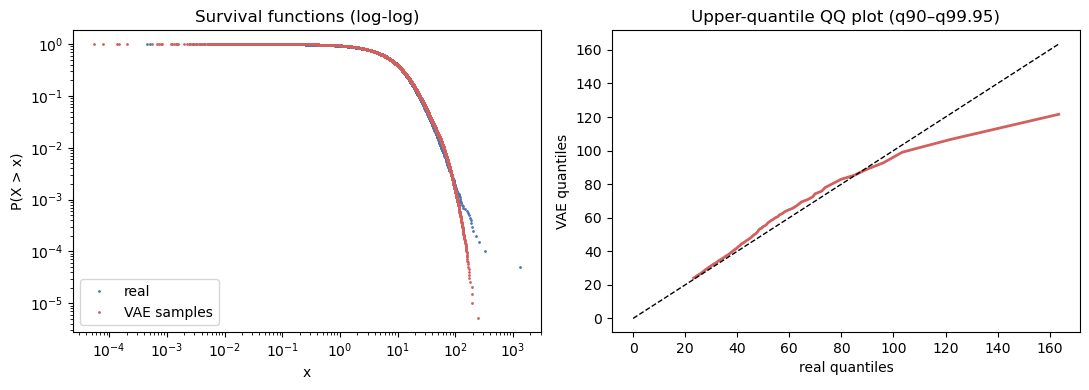

                                real         VAE
Hill tail index                 2.82        5.31   (true = 3)
P(X > q99_real)               0.0100      0.0128
P(X > q99.9_real)             0.0010      0.0005
sample max                    1302.3       242.5


In [7]:
M = 200_000
gen = (vae.sample(M).squeeze().numpy() * SD) + MU
gen_pos = gen[gen > 0]           # keep the physically meaningful (positive) part for tail work

def hill(a, k=500):
    s = np.sort(a)[::-1][: k + 1]
    return 1.0 / np.mean(np.log(s[:-1]) - np.log(s[-1]))

q99, q999 = np.quantile(x, [0.99, 0.999])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

gs = np.sort(gen_pos)
ax[0].loglog(xs, surv, ".", ms=2, color="#4878b0", label="real")
ax[0].loglog(gs, 1 - np.arange(1, len(gs) + 1) / (len(gs) + 1), ".", ms=2,
             color="#d1605e", label="VAE samples")
ax[0].set(title="Survival functions (log-log)", xlabel="x", ylabel="P(X > x)")
ax[0].legend()

qs = np.linspace(0.90, 0.9995, 200)
ax[1].plot(np.quantile(x, qs), np.quantile(gen_pos, qs), color="#d1605e", lw=2)
lim = [0, np.quantile(x, qs).max()]
ax[1].plot(lim, lim, "k--", lw=1)
ax[1].set(title="Upper-quantile QQ plot (q90–q99.95)",
          xlabel="real quantiles", ylabel="VAE quantiles")
plt.tight_layout(); plt.show()

print(f"{'':24s}{'real':>12s}{'VAE':>12s}")
print(f"{'Hill tail index':24s}{hill(x):>12.2f}{hill(gen_pos):>12.2f}   (true = 3)")
print(f"{'P(X > q99_real)':24s}{0.01:>12.4f}{np.mean(gen > q99):>12.4f}")
print(f"{'P(X > q99.9_real)':24s}{0.001:>12.4f}{np.mean(gen > q999):>12.4f}")
print(f"{'sample max':24s}{x.max():>12.1f}{gen.max():>12.1f}")

### What we see

Two distinct failures, and they point in *opposite* directions:

- **The far tail is starved:** The VAE's survival curve bends down and dies where the real one keeps going as a straight line. The Hill index of the generated samples is far above 3, the VAE's tail is much *lighter* than reality. Most tellingly, across 200k generated samples (10× the training set) the VAE's largest event is a fraction of the largest *observed* event. The model cannot produce the scenario that already happened, let alone a plausible worse one.
- **The moderate tail is smeared:** Exceedances of the real 99% quantile are slightly over-produced. The Gaussian decoder, forced to cover heavy-tailed data with light-tailed noise, inflates its variance in the bulk, spilling probability mass into the moderate-exceedance region while still truncating the far tail.

For crisis-scenario generation this is the worst possible combination: the generator **over-samples nuisance-level events and censors catastrophes.**

### Why this happens 

A latent Gaussian pushed through a well-behaved (locally Lipschitz) network cannot manufacture polynomial tails: the output inherits essentially Gaussian-type tail decay. This has been formalised for normalizing flows (Jaini et al., ICML 2020, *Tails of Lipschitz triangular flows*), and the same mechanism constrains VAE decoders while the learned observation variance only mixes in Gaussian noise, which yields light tails as well. Training data scarcity in the tail compounds the problem, with $\alpha = 3$, the top0.1% of events carry a large share of the risk but contribute almost nothing to the ELBO.

**The failure is structural, so the fix should be structural too.**

## 5. The EVT corrective: a VAE-bulk / GPD-tail hybrid

Extreme value theory tells us exactly what the tail *should* look like. The **Pickands–Balkema–de Haan theorem**: for a high threshold $u$, exceedances $X - u \mid X > u$ converge to a **Generalized Pareto Distribution**,

$$P(X - u > y \mid X > u) \;\approx\; \left(1 + \xi \frac{y}{\beta}\right)^{-1/\xi}$$

with shape $\xi = 1/\alpha$ (here $\xi \approx 1/3$). This suggests a *spliced* generator:

- **bulk** ($x \le u$): sample from the VAE, deep generative models are good at flexible bulk modelling, and this is where they can later absorb covariates, dependence structure, multimodality.
- **tail** ($x > u$): sample $u + \mathrm{GPD}(\xi, \beta)$, with $(\xi, \beta)$ fitted by peaks-over-threshold on the real exceedances.
- mix with weight $p_u = P(X > u)$ estimated empirically.

Each component does what it is provably good at.

POT fit at u = q95 = 31.7:  xi = 0.286  (theory 1/3 = 0.333),  beta = 12.89


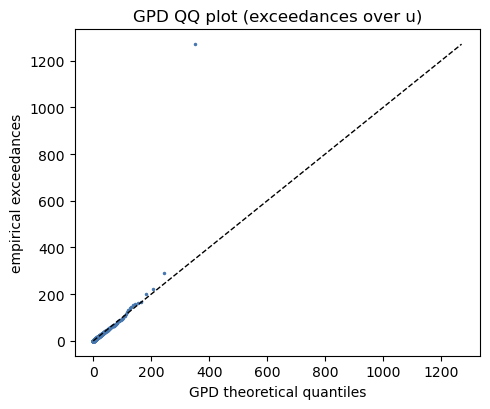

In [8]:
u = np.quantile(x, 0.95)                    
p_u = 0.05
exc = x[x > u] - u
xi_hat, _, beta_hat = stats.genpareto.fit(exc, floc=0)
print(f"POT fit at u = q95 = {u:.1f}:  xi = {xi_hat:.3f}  (theory 1/3 = 0.333),  beta = {beta_hat:.2f}")

# GPD goodness-of-fit on exceedances
plt.figure(figsize=(5, 4.2))
p = (np.arange(1, len(exc) + 1) - 0.5) / len(exc)
plt.plot(stats.genpareto.ppf(p, xi_hat, 0, beta_hat), np.sort(exc), ".", ms=3, color="#4878b0")
lim = [0, np.sort(exc)[-1]]
plt.plot(lim, lim, "k--", lw=1)
plt.xlabel("GPD theoretical quantiles"); plt.ylabel("empirical exceedances")
plt.title("GPD QQ plot (exceedances over u)")
plt.tight_layout(); plt.show()

# Hybrid sampler
is_tail = np.random.rand(M) < p_u
bulk_pool = gen[(gen > 0) & (gen <= u)]
hyb = np.where(is_tail,
               u + stats.genpareto.rvs(xi_hat, loc=0, scale=beta_hat, size=M),
               np.random.choice(bulk_pool, size=M))

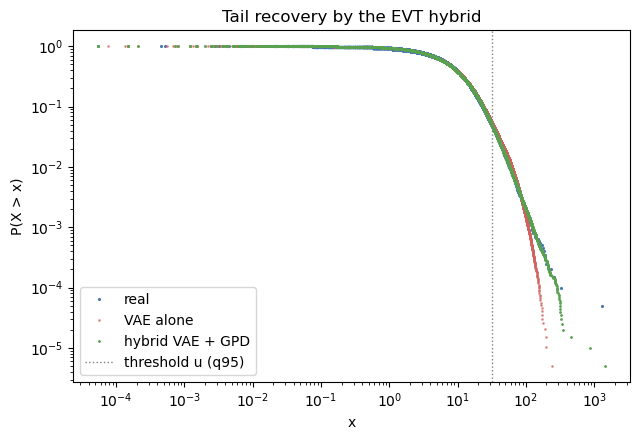

                                real       VAE    hybrid
Hill tail index (true=3)       2.819     5.314     2.993
P(X > q99_real)                 0.01   0.01283   0.01034
P(X > q99.9_real)              0.001   0.00048  0.001085
sample max                      1302     242.5      1425


In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
hs = np.sort(hyb)
ax.loglog(xs, surv, ".", ms=2.5, color="#4878b0", label="real")
ax.loglog(gs, 1 - np.arange(1, len(gs) + 1) / (len(gs) + 1), ".", ms=2,
          color="#d1605e", alpha=0.6, label="VAE alone")
ax.loglog(hs, 1 - np.arange(1, len(hs) + 1) / (len(hs) + 1), ".", ms=2,
          color="#59a14f", label="hybrid VAE + GPD")
ax.axvline(u, color="gray", ls=":", lw=1, label="threshold u (q95)")
ax.set(title="Tail recovery by the EVT hybrid", xlabel="x", ylabel="P(X > x)")
ax.legend()
plt.tight_layout(); plt.show()

rows = [("Hill tail index (true=3)", hill(x), hill(gen_pos), hill(hyb)),
        ("P(X > q99_real)",          0.01,    np.mean(gen > q99),  np.mean(hyb > q99)),
        ("P(X > q99.9_real)",        0.001,   np.mean(gen > q999), np.mean(hyb > q999)),
        ("sample max",               x.max(), gen.max(),           hyb.max())]
print(f"{'':26s}{'real':>10s}{'VAE':>10s}{'hybrid':>10s}")
for name, a, b, c in rows:
    print(f"{name:26s}{a:>10.4g}{b:>10.4g}{c:>10.4g}")

The hybrid's survival curve tracks the real one across the entire range of the tail index, the extreme exceedance probabilities and the magnitude of the largest generated event are all restored, while the bulk remains the VAE's.

## 6. Discussion: what this means for crisis-scenario generation

**The core idea:** Using generative AI to enrich scarce crisis data is a sound idea, but *plausibility must be defined and verified in the tail*, because the tail is where the value of synthetic scenarios lies. EVT supplies exactly the missing pieces:

- **as a diagnostic:** tail-index estimation, survival-curve comparison and extreme-quantile QQ plots should be part of the standard validation battery for any generative scenario model;
- **as a corrective:** POT/GPD splicing, or more deeply, heavy-tailed priors and decoders, tail-weighted objectives, or EVT-regularised training.

**Why the hybrid design generalises:** Nothing in the splice construction is specific to this toy. In a realistic setting, e.g. stress scenarios for infrastructure sites exposed to storms. The VAE/GAN component earns its keep by modelling what EVT alone cannot: covariates (site characteristics, seasonality), multivariate dependence between hazard drivers, and non-stationarity. The EVT component guarantees that whatever is generated respects asymptotic tail behaviour. The two are complementary, not competing.

**Honest limitations of this experiment:**
- One-dimensional, i.i.d., stationary. Real crisis modelling is multivariate (wind × rain × flood), spatially and temporally dependent, and non-stationary under climate change. Multivariate tail dependence is the natural next question, and standard generative models are known to distort it too.
- The POT threshold ($u$ = q95 here) was fixed, not selected, mean-excess plots and stability analysis  would be required in practice.
- The comparison uses a single seed and architecture, a careful study would sweep both.

**Natural extensions:** conditional generation $p(x \mid \text{covariates})$ with the same tail-spliced validation, bivariate hazards with tail-dependence diagnostics ($\chi$-measure), heavy-tailed latent priors (Student-$t$) as an internal alternative to external splicing, and non-stationary GPD parameters $\xi(t), \beta(t)$ linking the corrective to climate-change attribution methods.

## References

- Coles, S. (2001). *An Introduction to Statistical Modeling of Extreme Values.* Springer.
- Jaini, P., Kobyzev, I., Yu, Y., Brubaker, M. (2020). Tails of Lipschitz Triangular Flows. *ICML.*